# Random Forest in a classification task.


In [1]:
#adopted from github.com/Yorko/mlcourse.ai/

In [2]:
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (GridSearchCV, cross_val_score,
                                     train_test_split, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
import seaborn as sns

**We are working with UCI Wine quality dataset**

In [3]:
data = pd.read_csv("winequality-white.csv", sep=";")

In [4]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [15]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


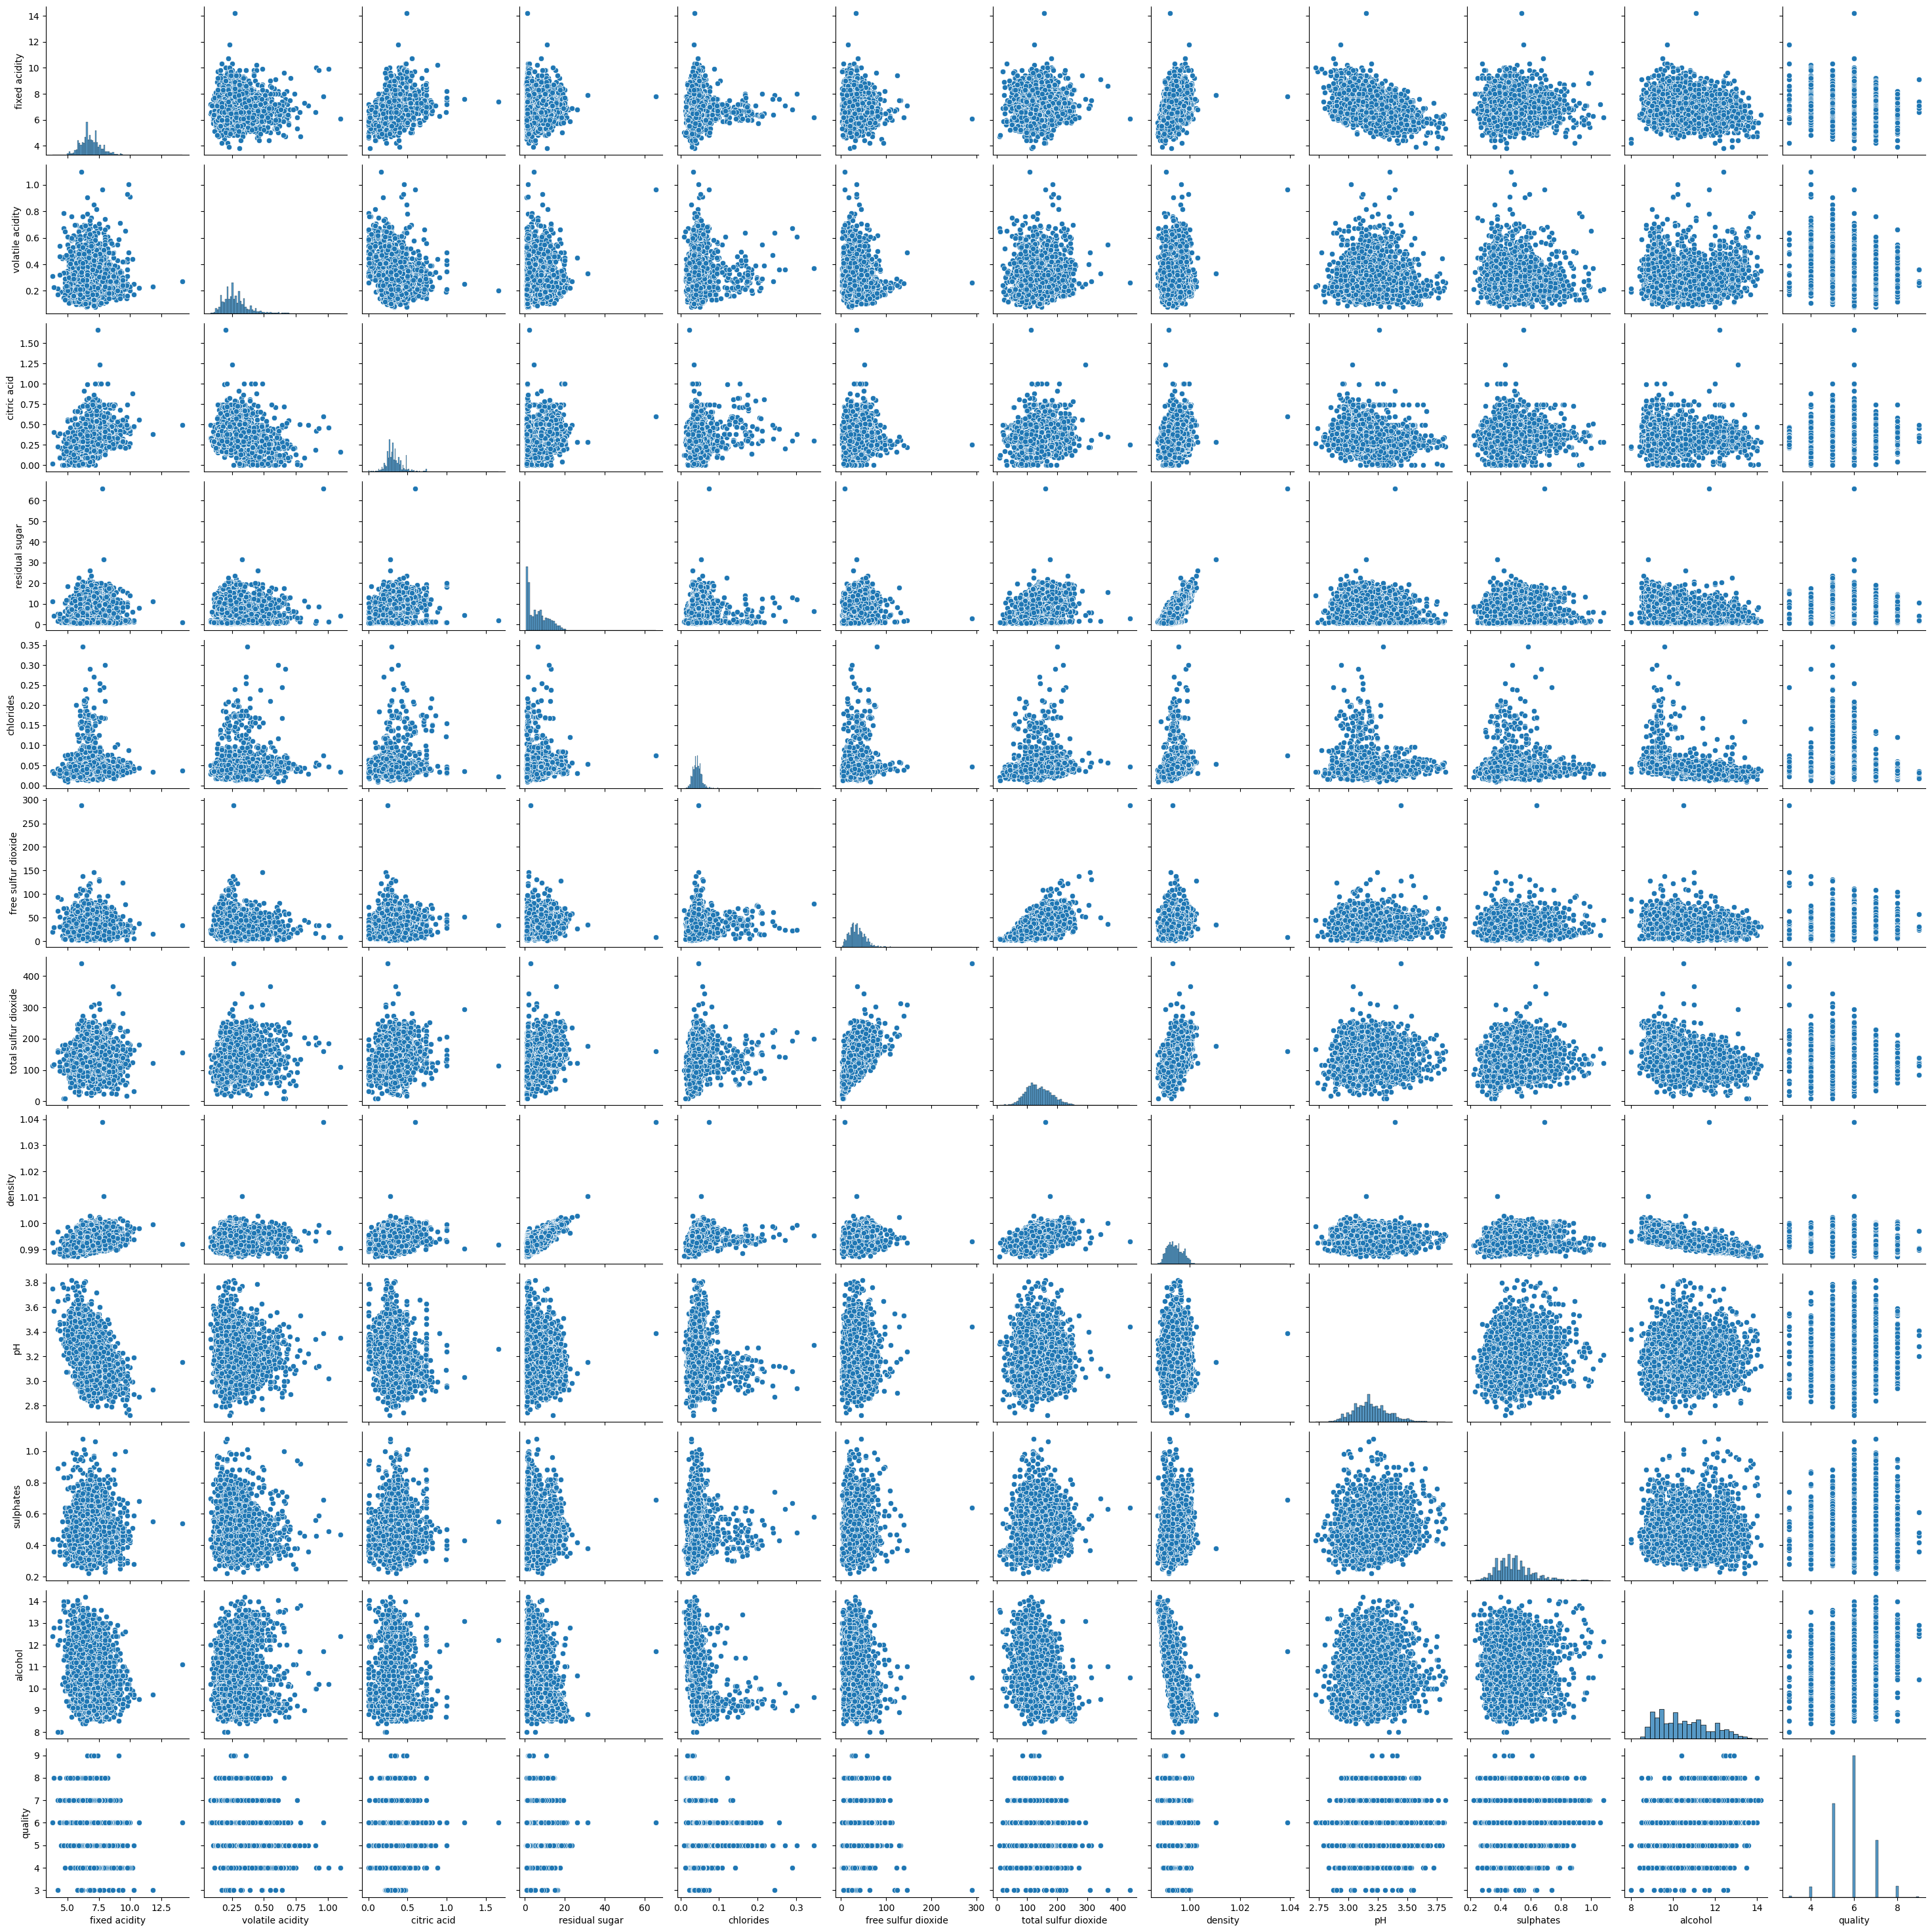

In [6]:
sns.pairplot(data)

<Axes: >

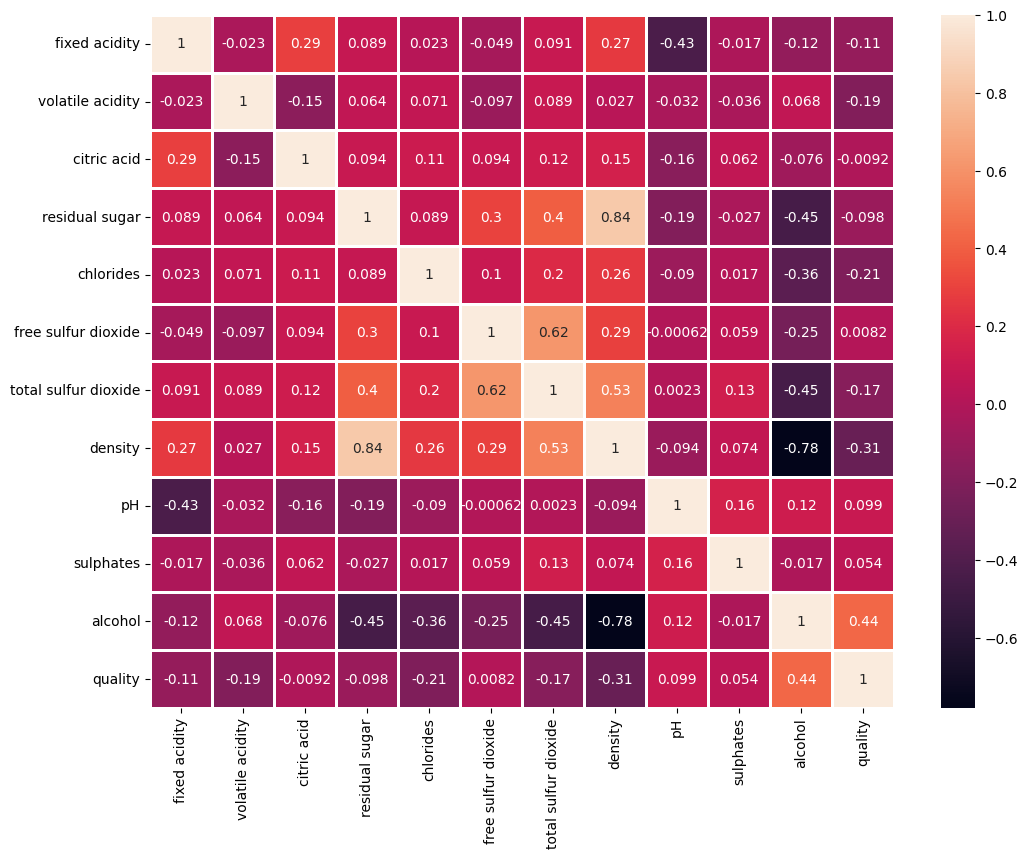

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,9))
sns.heatmap(data.corr(),annot=True,linewidths=2)

**Separate the target feature, split data in 7:3 proportion (30% form a holdout set, use random_state=17), and preprocess data with `StandardScaler`.**

In [8]:
y = data["quality"]
X = data.drop("quality", axis=1)

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.3, random_state=17
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)

In [9]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train);

**What are mean squared errors of model predictions on train and holdout sets?**

In [10]:
print(
    "Mean squared error (train): %.3f"
    % mean_squared_error(y_train, linreg.predict(X_train_scaled))
)
print(
    "Mean squared error (test): %.3f"
    % mean_squared_error(y_holdout, linreg.predict(X_holdout_scaled))
)

Mean squared error (train): 0.558
Mean squared error (test): 0.584


In [11]:
from sklearn.metrics import r2_score

#print("R-squared value of predictions:",round(metrics.r2_score(y_test,predictions),3))
print(
    "R-squared value  (train): %.3f"
    % round(r2_score(y_train, linreg.predict(X_train_scaled)),3)
)
print(
    "R-squared value  (test): %.3f"
    % round(r2_score(y_holdout, linreg.predict(X_holdout_scaled)),3)
)

R-squared value  (train): 0.290
R-squared value  (test): 0.250


**Sort features by their influence on the target feature (wine quality). Beware that both large positive and large negative coefficients mean large influence on target. It's handy to use `pandas.DataFrame` here.**

Which feature this linear regression model treats as the most influential on wine quality?

In [12]:
linreg_coef = pd.DataFrame(
    {"coef": linreg.coef_, "coef_abs": np.abs(linreg.coef_)},
    index=data.columns.drop("quality"),
)
linreg_coef.sort_values(by="coef_abs", ascending=False)

,coef,coef_abs
density,-0.665720,0.665720
residual sugar,0.538164,0.538164
volatile acidity,-0.192260,0.192260
pH,0.150036,0.150036
alcohol,0.129533,0.129533
fixed acidity,0.097822,0.097822
sulphates,0.062053,0.062053
free sulfur dioxide,0.042180,0.042180
total sulfur dioxide,0.014304,0.014304
chlorides,0.008127,0.008127


In [17]:
from sklearn.linear_model import LogisticRegression
LR1 = LogisticRegression(max_iter=1000, random_state=17)
LR1.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",17
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [19]:
# confusion matrix and classification report(precision, recall, F1-score)
print(classification_report(y_train, LR1.predict(X_train_scaled)))
print(confusion_matrix(y_train, LR1.predict(X_train_scaled)))

              precision    recall  f1-score   support

           3       0.67      0.13      0.22        15
           4       0.75      0.10      0.18       117
           5       0.59      0.51      0.55      1004
           6       0.53      0.77      0.63      1567
           7       0.51      0.23      0.32       593
           8       0.00      0.00      0.00       128
           9       0.00      0.00      0.00         4

    accuracy                           0.55      3428
   macro avg       0.44      0.25      0.27      3428
weighted avg       0.53      0.55      0.51      3428

[[   2    0    7    5    1    0    0]
 [   0   12   60   44    1    0    0]
 [   0    2  513  481    8    0    0]
 [   1    2  271 1210   83    0    0]
 [   0    0   16  440  137    0    0]
 [   0    0    1   91   36    0    0]
 [   0    0    0    0    4    0    0]]


In [20]:
# confusion matrix and classification report(precision, recall, F1-score)
print(classification_report(y_holdout, LR1.predict(X_holdout_scaled)))
print(confusion_matrix(y_holdout, LR1.predict(X_holdout_scaled)))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00        46
           5       0.61      0.50      0.55       453
           6       0.50      0.78      0.61       631
           7       0.55      0.22      0.31       287
           8       0.00      0.00      0.00        47
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1470
   macro avg       0.24      0.21      0.21      1470
weighted avg       0.51      0.53      0.49      1470

[[  0   0   1   4   0   0   0]
 [  0   0  30  16   0   0   0]
 [  0   2 225 225   1   0   0]
 [  0   2 100 491  38   0   0]
 [  0   0  13 212  62   0   0]
 [  0   0   2  33  12   0   0]
 [  0   0   0   1   0   0   0]]


In [24]:
print(
    "accuracy score (train): %.3f"
    % accuracy_score(y_train, LR1.predict(X_train_scaled))
)
print(
    "accuracy score (cv): %.3f"
    % np.mean(
        np.abs(
            cross_val_score(
                LR1, X_train_scaled, y_train, scoring='accuracy'
            )
        )
    )
)
print(
    "accuracy score (test): %.3f"
    % accuracy_score(y_holdout, LR1.predict(X_holdout_scaled))
)

accuracy score (train): 0.547
accuracy score (cv): 0.541
accuracy score (test): 0.529


In [21]:
from sklearn.svm import SVC

svc1 = SVC(random_state=42)
svc1.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [22]:
# confusion matrix and classification report(precision, recall, F1-score)
print(classification_report(y_train, svc1.predict(X_train_scaled)))
print(confusion_matrix(y_train, svc1.predict(X_train_scaled)))

              precision    recall  f1-score   support

           3       1.00      0.20      0.33        15
           4       1.00      0.13      0.23       117
           5       0.67      0.64      0.65      1004
           6       0.59      0.82      0.68      1567
           7       0.67      0.30      0.41       593
           8       0.00      0.00      0.00       128
           9       0.00      0.00      0.00         4

    accuracy                           0.62      3428
   macro avg       0.56      0.30      0.33      3428
weighted avg       0.62      0.62      0.58      3428

[[   3    0    5    7    0    0    0]
 [   0   15   59   42    1    0    0]
 [   0    0  638  366    0    0    0]
 [   0    0  236 1287   44    0    0]
 [   0    0   11  406  176    0    0]
 [   0    0    0   89   39    0    0]
 [   0    0    0    1    3    0    0]]


In [23]:
# confusion matrix and classification report(precision, recall, F1-score)
print(classification_report(y_holdout, svc1.predict(X_holdout_scaled)))
print(confusion_matrix(y_holdout, svc1.predict(X_holdout_scaled)))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       1.00      0.02      0.04        46
           5       0.64      0.57      0.61       453
           6       0.52      0.80      0.63       631
           7       0.65      0.23      0.34       287
           8       0.00      0.00      0.00        47
           9       0.00      0.00      0.00         1

    accuracy                           0.56      1470
   macro avg       0.40      0.23      0.23      1470
weighted avg       0.58      0.56      0.52      1470

[[  0   0   1   4   0   0   0]
 [  0   1  31  14   0   0   0]
 [  0   0 260 193   0   0   0]
 [  0   0 103 502  26   0   0]
 [  0   0  10 212  65   0   0]
 [  0   0   1  37   9   0   0]
 [  0   0   0   1   0   0   0]]


In [25]:
print(
    "accuracy score (train): %.3f"
    % accuracy_score(y_train, svc1.predict(X_train_scaled))
)
print(
    "accuracy score (cv): %.3f"
    % np.mean(
        np.abs(
            cross_val_score(
                svc1, X_train_scaled, y_train, scoring='accuracy'
            )
        )
    )
)
print(
    "accuracy score (test): %.3f"
    % accuracy_score(y_holdout, svc1.predict(X_holdout_scaled))
)

accuracy score (train): 0.618
accuracy score (cv): 0.573
accuracy score (test): 0.563


## Random Forest

**Train a Random Forest with out-of-the-box parameters, setting only random_state to be 17.**

In [22]:
set(list(y_train.values))

{np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)}

In [13]:
forest = RandomForestClassifier(criterion='entropy', random_state=17)
forest.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

**What are mean squared errors of RF model on the training set, in cross-validation (cross_val_score with scoring='neg_mean_squared_error' and other arguments left with default values) and on holdout set?**

In [14]:
# confusion matrix and classification report(precision, recall, F1-score)
print(classification_report(y_train, forest.predict(X_train_scaled)))
print(confusion_matrix(y_train, forest.predict(X_train_scaled)))

              precision    recall  f1-score   support

           3       1.00      1.00      1.00        15
           4       1.00      1.00      1.00       117
           5       1.00      1.00      1.00      1004
           6       1.00      1.00      1.00      1567
           7       1.00      1.00      1.00       593
           8       1.00      1.00      1.00       128
           9       1.00      1.00      1.00         4

    accuracy                           1.00      3428
   macro avg       1.00      1.00      1.00      3428
weighted avg       1.00      1.00      1.00      3428

[[  15    0    0    0    0    0    0]
 [   0  117    0    0    0    0    0]
 [   0    0 1004    0    0    0    0]
 [   0    0    0 1567    0    0    0]
 [   0    0    0    0  593    0    0]
 [   0    0    0    0    0  128    0]
 [   0    0    0    0    0    0    4]]


In [25]:
# confusion matrix and classification report(precision, recall, F1-score)
print(classification_report(y_holdout, forest.predict(X_holdout_scaled)))
print(confusion_matrix(y_holdout, forest.predict(X_holdout_scaled)))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.60      0.20      0.30        46
           5       0.74      0.67      0.70       453
           6       0.62      0.82      0.71       631
           7       0.74      0.48      0.58       287
           8       0.91      0.43      0.58        47
           9       0.00      0.00      0.00         1

    accuracy                           0.67      1470
   macro avg       0.52      0.37      0.41      1470
weighted avg       0.69      0.67      0.66      1470

[[  0   0   1   4   0   0   0]
 [  0   9  25  12   0   0   0]
 [  0   4 304 143   2   0   0]
 [  0   1  75 519  35   1   0]
 [  0   1   7 140 138   1   0]
 [  0   0   0  16  11  20   0]
 [  0   0   0   1   0   0   0]]


In [16]:
print(
    "accuracy score (train): %.3f"
    % accuracy_score(y_train, forest.predict(X_train_scaled))
)
print(
    "accuracy score (cv): %.3f"
    % np.mean(
        np.abs(
            cross_val_score(
                forest, X_train_scaled, y_train, scoring='accuracy'
            )
        )
    )
)
print(
    "accuracy score (test): %.3f"
    % accuracy_score(y_holdout, forest.predict(X_holdout_scaled))
)

accuracy score (train): 1.000
accuracy score (cv): 0.650
accuracy score (test): 0.673


**Tune the `max_features` and `max_depth` hyperparameters with GridSearchCV and again check mean cross-validation MSE and MSE on holdout set.**

In [30]:
forest_params = {"max_depth": list(range(10, 25)), "max_features": list(range(6, 12))}

locally_best_forest = GridSearchCV(
    RandomForestClassifier(n_jobs=1, random_state=17),
    forest_params,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
    verbose=True,
)
locally_best_forest.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 11, ...], 'max_features': [6, 7, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [31]:
locally_best_forest.best_params_, locally_best_forest.best_score_

({'max_depth': 16, 'max_features': 9}, np.float64(0.6499389244748994))

**What are mean squared errors of tuned RF model in cross-validation (cross_val_score with scoring='neg_mean_squared_error' and other arguments left with default values) and on holdout set?**

In [32]:
print(
    "accuracy_score (cv): %.3f"
    % np.mean(
        np.abs(
            cross_val_score(
                locally_best_forest.best_estimator_,
                X_train_scaled,
                y_train,
                scoring="accuracy",
            )
        )
    )
)
print(
    "accuracy_score (test): %.3f"
    % accuracy_score(y_holdout, locally_best_forest.predict(X_holdout_scaled))
)

accuracy_score (cv): 0.650
accuracy_score (test): 0.664


In [33]:
print(classification_report(y_holdout, locally_best_forest.predict(X_holdout_scaled)))
print(confusion_matrix(y_holdout, locally_best_forest.predict(X_holdout_scaled)))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.58      0.24      0.34        46
           5       0.71      0.66      0.68       453
           6       0.63      0.80      0.70       631
           7       0.71      0.48      0.57       287
           8       0.87      0.43      0.57        47
           9       0.00      0.00      0.00         1

    accuracy                           0.66      1470
   macro avg       0.50      0.37      0.41      1470
weighted avg       0.67      0.66      0.65      1470

[[  0   0   2   3   0   0   0]
 [  0  11  24  11   0   0   0]
 [  0   6 299 142   6   0   0]
 [  0   1  84 507  38   1   0]
 [  0   1  14 131 139   2   0]
 [  0   0   0  13  14  20   0]
 [  0   0   0   1   0   0   0]]


**Output RF's feature importance. Again, it's nice to present it as a DataFrame.**<br>
**What is the most important feature, according to the Random Forest model?**

In [34]:
rf_importance = pd.DataFrame(
    locally_best_forest.best_estimator_.feature_importances_,
    columns=["coef"],
    index=data.columns[:-1],
)
rf_importance.sort_values(by="coef", ascending=False)

,coef
alcohol,0.137594
volatile acidity,0.105755
free sulfur dioxide,0.094827
total sulfur dioxide,0.090794
pH,0.088119
density,0.084073
chlorides,0.083238
residual sugar,0.082153
citric acid,0.079402
sulphates,0.079341


In [21]:
forest_params = {"n_estimators": list(range(10,1000,40)), "max_depth": list(range(10, 25)), "max_features": list(range(6, 12))}

locally_best_forest_R = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=17),
    forest_params,
    scoring="accuracy",
    n_jobs=-1,
    cv=5,
    verbose=True,
)
locally_best_forest_R.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=17),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24],
                                        'max_features': [6, 7, 8, 9, 10, 11],
                                        'n_estimators': [10, 50, 90, 130, 170,
                                                         210, 250, 290, 330,
                                                         370, 410, 450, 490,
                                                         530, 570, 610, 650,
                                                         690, 730, 770, 810,
                                                         850, 890, 930, 970]},
                   scoring='accuracy', verbose=True)

In [22]:
locally_best_forest_R.best_params_, locally_best_forest.best_score_

({'n_estimators': 330, 'max_features': 7, 'max_depth': 17}, 0.6499389244748994)

In [23]:
print(
    "accuracy score (cv): %.3f"
    % np.mean(
        np.abs(
            cross_val_score(
                locally_best_forest_R.best_estimator_,
                X_train_scaled,
                y_train,
                scoring="accuracy",
            )
        )
    )
)
print(
    "accuracy score (test): %.3f"
    % accuracy_score(y_holdout, locally_best_forest_R.predict(X_holdout_scaled))
)

accuracy score (cv): 0.650
accuracy score (test): 0.668


In [24]:
rf_importance = pd.DataFrame(
    locally_best_forest_R.best_estimator_.feature_importances_,
    columns=["coef"],
    index=data.columns[:-1],
)
rf_importance.sort_values(by="coef", ascending=False)

,coef
alcohol,0.128105
volatile acidity,0.102961
free sulfur dioxide,0.095048
density,0.094931
total sulfur dioxide,0.089246
pH,0.087975
chlorides,0.084447
residual sugar,0.083544
citric acid,0.079420
sulphates,0.078871
